In [6]:
import matplotlib.pyplot as plt
from os import environ
'''environ["OMP_NUM_THREADS"] = "1"
environ["OPENBLAS_NUM_THREADS"] = "1"
environ["MKL_NUM_THREADS"] = "1"
environ["VECLIB_MAXIMUM_THREADS"] = "1"
environ["NUMEXPR_NUM_THREADS"] = "1"'''
import numpy as np
import math
import multiprocessing
from multiprocessing import Pool
import csv
from numpy import linalg as la
#from scipy.stats import kde
#from scipy.fftpack import fft, ifft
#from IPython import get_ipython;   
#from itertools import repeat, izip
#get_ipython().magic('reset -sf')
#plt.close('all')

n = 10000
sigma = np.sqrt(2.6)
mu = 0.0
gammax = 0.0
r = 1.2

a = 0.2

eff0 = 0.001


tmax = 1000


numtrial = 1
kbound = 1.0

numsample = 1000



if __name__ == '__main__':


    sampvec = np.zeros(numsample)
    
    
    axx = np.zeros((n,n))
                
    #construct random interaction matrix
    for i in range(0,n):
        for k in range(0,i):
            rand2 = np.random.uniform(0.0,1.0, 1)[0]
            rand3 = np.random.uniform(0.0,1.0, 1)[0]
            if rand2<0.5:
                axx[i][k] = -sigma/np.sqrt(n)
            if rand2>0.5:
                axx[i][k] = sigma/np.sqrt(n)
            if rand3<0.5:
                axx[k][i] = -sigma/np.sqrt(n)
            if rand3>0.5:
                axx[k][i] = sigma/np.sqrt(n)
            '''axx[i][k] = np.random.normal(0.0, sigma/np.sqrt(n), 1)[0]
            axx[k][i] = np.random.normal(0.0, sigma/np.sqrt(n), 1)[0]'''


        
    x = np.ones(n)*(1.0-1.0/r)
    step = 0
    t = 0
    #Numerical integration
    while t <= tmax:

        x = r*x*(1.0 - x + axx.dot(x))*np.heaviside(r*x*(1.0 - x + axx.dot(x)),0.0)*np.heaviside(kbound-r*x*(1.0 - x + axx.dot(x)),0.0) + kbound*(1.0-np.heaviside(kbound-r*x*(1.0 - x + axx.dot(x)),0.0)) + 0.0001


        step = step +1
        t = t + 1

    flag = 0
    ind = 0
    while flag==0:
        if(x[ind]>eff0 and x[ind]<1.0-eff0):
            flag = 1
        ind = ind +1

    ind = ind-1
    step = 0
    while t <= tmax + numsample:

        x = r*x*(1.0 - x + axx.dot(x))*np.heaviside(r*x*(1.0 - x + axx.dot(x)),0.0)*np.heaviside(kbound-r*x*(1.0 - x + axx.dot(x)),0.0) + kbound*(1.0-np.heaviside(kbound-r*x*(1.0 - x + axx.dot(x)),0.0)) + 0.0001

        sampvec[step] = np.copy(x[ind])
        step = step +1
        t = t + 1

        
    xstar = np.copy(x)
    yvec = 1.0 - x + axx.dot(x)
    ystar = 1.0 - x + axx.dot(x)
    ystar1 = 1.0 - x + axx.dot(x)

    x1 = np.copy(x)
    x = r*x*(1.0 - x + axx.dot(x))*np.heaviside(r*x*(1.0 - x + axx.dot(x)),0.0)*np.heaviside(kbound-r*x*(1.0 - x + axx.dot(x)),0.0) + kbound*(1.0-np.heaviside(kbound-r*x*(1.0 - x + axx.dot(x)),0.0))
    x2 = np.copy(x)
    ystar2 = 1.0 - x2 + axx.dot(x2)

    
    sol1 = 1.0-1.0/r + axx.dot(x1) - axx.dot(x1-x2)/(3.0-r-r*axx.dot(2.0*x1-x2))
    sol2 = 1.0-1.0/r + axx.dot(x2) - axx.dot(x2-x1)/(3.0-r-r*axx.dot(2.0*x2-x1))

    x1star = np.copy(x1)
    x2star = np.copy(x2)

    print("Run complete")
    
    nstar = np.copy(n)
    for k in range(0,n):
        if x[k] <eff0 or x[k]>1.0-eff0:
            axx = np.delete(axx, k-(n-nstar), 0)
            axx = np.delete(axx, k-(n-nstar), 1)
            xstar = np.delete(xstar, k-(n-nstar), 0)
            ystar = np.delete(ystar, k-(n-nstar), 0)
            ystar1 = np.delete(ystar1, k-(n-nstar), 0)
            ystar2 = np.delete(ystar2, k-(n-nstar), 0)
            x1star = np.delete(x1star, k-(n-nstar), 0)
            x2star = np.delete(x2star, k-(n-nstar), 0)
            nstar = nstar - 1
	
    xdiag = np.diag(xstar)
    sum2 = axx.dot(xdiag.dot(axx))    
    id = np.identity(nstar)
        
    #jac = np.zeros((2*nstar,2*nstar))
    #m3= np.zeros((2*nstar,2*nstar))
    jac1 = np.zeros((nstar,nstar))
    #m3 = np.zeros((nstar,nstar))
    #m4 = np.zeros((nstar,nstar))
    #jac2 = np.zeros((nstar,nstar))
    #m = np.zeros((nstar,nstar))
    #m2 = np.zeros((nstar,nstar))


    for i in range(0,nstar):
        #sum2fake[i][i]=0
        for j in range(0, nstar):
            #jac[i][j+nstar] = id[i][j]*(r*ystar2[i]- r*x2star[i]) + r*x2star[i]*axx[i][j]
            #jac[i+nstar][j] = id[i][j]*(r*ystar1[i]- r*x1star[i]) + r*x1star[i]*axx[i][j]
            #m3[i][j] = id[i][j]*((ystar[i]-1.0/r)/xstar[i]- 1.0) + axx[i][j]
            #m4[i][j]  = id[i][j]*(1.0+r*ystar[i]- r*xstar[i]) + r*xstar[i]*axx[i][j]
            #m3[i+nstar][j] = id[i][j]*((ystar1[i]-1.0/r)/x1star[i]- 1.0) + axx[i][j]
            jac1[i][j] = id[i][j]*(1.0- r*xstar[i]) + r*xstar[i]*axx[i][j]
            #jac2[i][j] = id[i][j] + xstar[i]/ystar[i]*(axx[i][j]-id[i][j]) + r**2*xstar[i]*ystar[i]*(-r*ystar[j]*(id[i][j]-axx[i][j])- r*xstar[i]*(axx[i][j]-id[i][j])+r*sum2[i][j] - r*axx[i][j]*xstar[j])
            #m[i][j] = (jac2[i][j]-id[i][j])/xstar[i]
            #m2[i][j] = id[i][j]*(1.0/ystar[i] + r**3*ystar[i]*(ystar[i]-xstar[i])) + r**3*ystar[i]*axx[i][j]*xstar[j]
    

    print("Jacobian constructed")
    #evaluesm4, evectorsm4 = la.eig(m4)
    #evaluesm3, evectorsm3 = la.eig(m3)
    evaluesj1, evectorsj1 = la.eig(jac1)
    #evaluesj2, evectorsj2 = la.eig(jac2)
    #evaluesm, evectorsm = la.eig(m)
    #evaluesm2, evectorsm2 = la.eig(m2)
    evaluesa, evectorsa = la.eig(axx)
    print("Eigenvalues found")



    
    #np.savetxt("lambdaversusr_sig0point2_n8000.csv", lambdavec, delimiter=",")
    #np.savetxt("rvecsim_sig0point2_n8000.csv", rvec, delimiter=",")

    








Run complete
Jacobian constructed
Eigenvalues found


C:\Users\josep\AppData\Local\Temp\ipykernel_13620\296316076.py:166: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig1.show()
C:\Users\josep\AppData\Local\Temp\ipykernel_13620\296316076.py:188: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig1.show()
C:\Users\josep\AppData\Local\Temp\ipykernel_13620\296316076.py:207: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig1.show()
C:\Users\josep\AppData\Local\Temp\ipykernel_13620\296316076.py:224: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig1.show()
C:\Users\josep\AppData\Local\Temp\ipykernel_13620\296316076.py:248: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig1.show()
C:\Users\josep\AppData\Local\Temp\ipykernel_13620\296316076.py:269: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig1.show()


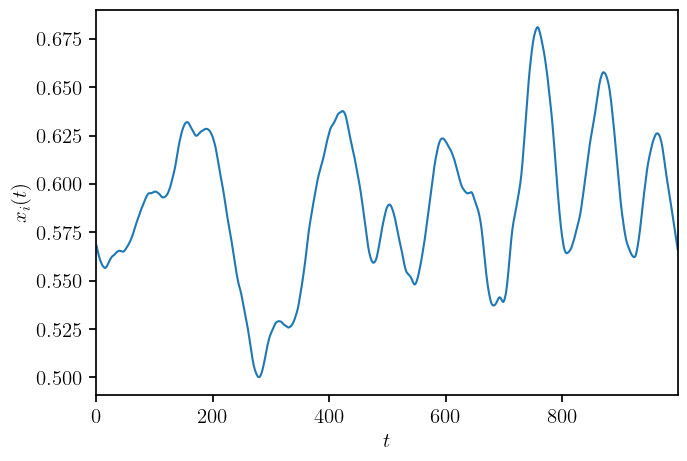

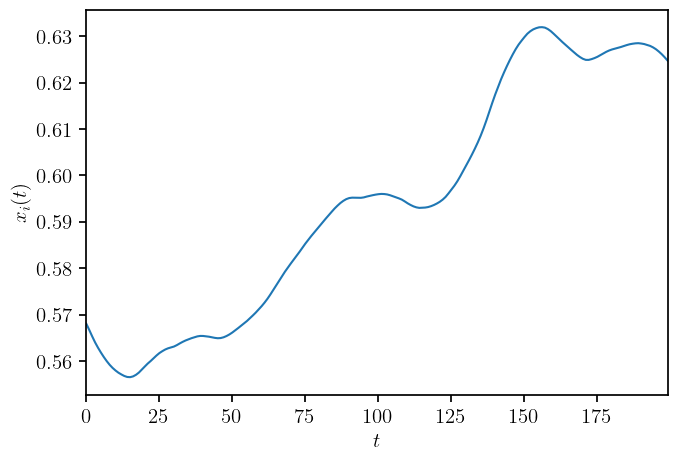

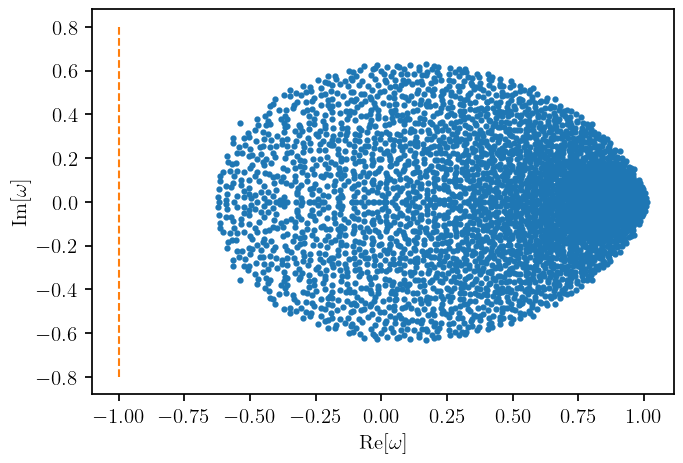

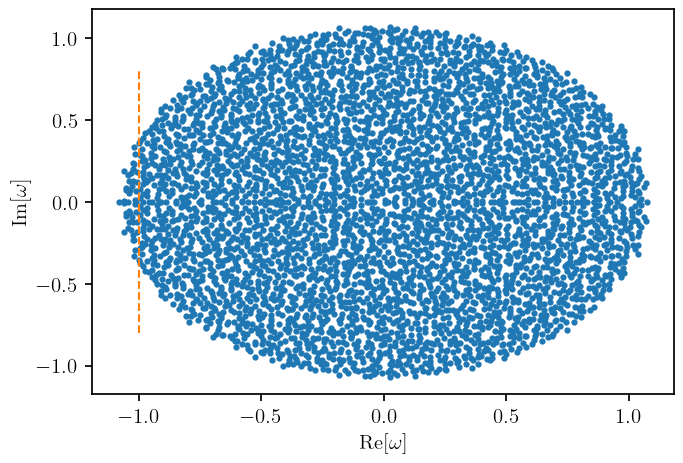

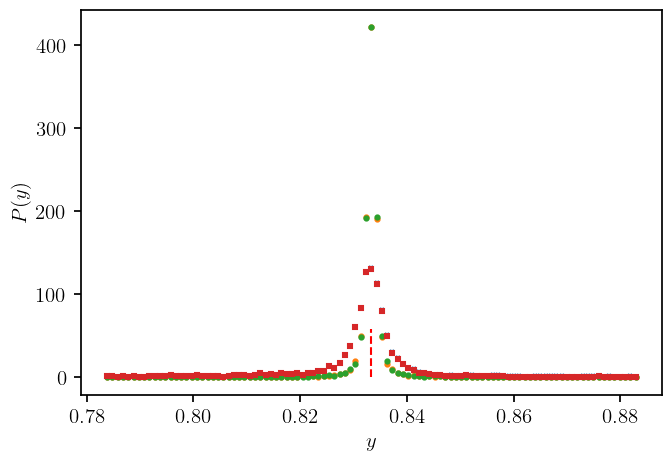

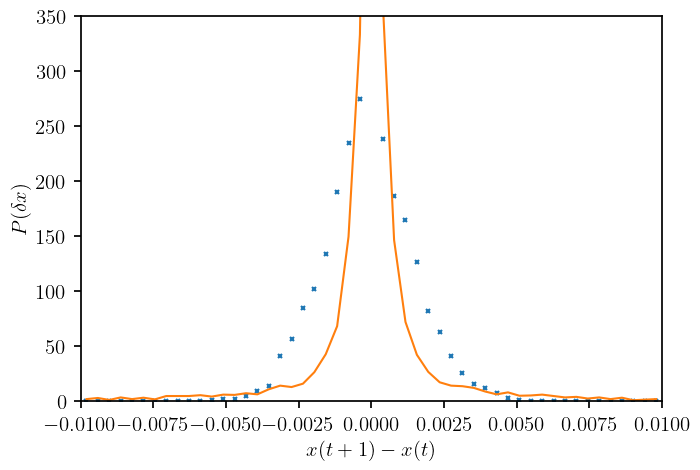

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import math
import multiprocessing
from multiprocessing import Pool
import csv
from numpy import linalg as la
#from scipy.stats import kde
#from itertools import repeat, izip
#from IPython import get_ipython;
#get_ipython().magic('reset -sf')
#plt.close('all')






eff0 = 0.001
effinf = 10.0**5


if __name__ == '__main__':


	xjmin =-1
	xjmax = 2.0
	numbins = 101
	binedges = np.linspace(xjmin, xjmax, numbins+1, endpoint=True)
	binsj = np.linspace(xjmin+float((xjmax-xjmin)/(numbins-1))*0.5, xjmax-float((xjmax-xjmin)/(numbins-1))*0.5, numbins, endpoint=True)		
	#realhist = np.histogram(np.real(evaluesj), binedges)[0]



	xmin = 0
	xmax = 1
	numbins = 51
	binedges = np.linspace(xmin, xmax, numbins+1, endpoint=True)
	bins = np.linspace(xmin+float((xmax-xmin)/(numbins-1))*0.5, xmax-float((xmax-xmin)/(numbins-1))*0.5, numbins, endpoint=True)		
	xhist = np.histogram(xstar, binedges)[0]



	q1 = sum(x1**2)/float(n)
	q2 = sum(x2**2)/float(n)
	q12 = sum(x1*x2)/float(n)

	mean = [0.0, 0.0]
	cov = [[sigma**2*(q1+q2)/2.0, sigma**2*q12], [sigma**2*q12, sigma**2*(q2+q1)/2.0]]
	numfakehist = 10000
	s1vec, s2vec = np.random.multivariate_normal(mean, cov, numfakehist).T
	#fakedx = (s1vec - s2vec)*(1.0- 1.0/(3.0-r+ r*s1vec )- 1.0/(3.0-r- r*s2vec ))
	fakedx = (s1vec - s2vec)*(1.0- 1.0/(3.0-r- r*s1vec  )- 1.0/(3.0-r- r*s2vec))
	#fakedx = (s1vec - s2vec)*(1.0- 1.0/(3.0-r)- 1.0/(3.0-r ))
	#fakey = (1.0 - fakex + axxbefore.dot(fakex))*np.heaviside(fakex, 0.0)*np.heaviside(1.0-fakex,0.0)
	#fakey1 = 1.0/r + (-s2star + s1star)/(3.0 - r -r*s1)
	#fakey2 = 1.0/r + (-s1star + s2star)/(3.0 - r -r*s2)

	fakey1 = 1/r + (-s2vec+ s1vec)/(3.0 - r -r*s1vec)
	fakey2 = 1.0/r + (-s1vec + s2vec)/(3.0 - r -r*s2vec)
	#fakey1 = 1/r + (-s2vec+ s1vec)/(3.0 - r )
	#fakey2 = 1.0/r + (-s1vec + s2vec)/(3.0 - r)
	
	fakex1 = np.heaviside(1.0-(1.0- 1.0/r + s1vec - (s1vec-s2vec)/(3.0 - r - r*s1vec)),0.0)*np.heaviside(1.0- 1.0/r + s1vec - (s1vec-s2vec)/(3.0 - r - r*s1vec),0.0)*(1.0- 1.0/r + s1vec - (s1vec-s2vec)/(3.0 - r - r*s1vec)) + np.heaviside((1.0- 1.0/r + s1vec - (s1vec-s2vec)/(3.0 - r - r*s1vec))-1.0,0.0)
	fakex2 = np.heaviside(1.0-(1.0- 1.0/r + s2vec - (s2vec-s1vec)/(3.0 - r - r*s2vec)),0.0)*np.heaviside((1.0- 1.0/r + s2vec - (s2vec-s1vec)/(3.0 - r - r*s2vec)),0.0)*(1.0- 1.0/r + s2vec - (s2vec-s1vec)/(3.0 - r - r*s2vec)) + np.heaviside((1.0- 1.0/r + s2vec - (s2vec-s1vec)/(3.0 - r - r*s2vec))-1.0,0.0)

	ymin = 1/r - 0.05
	ymax = 1/r + 0.05
	numbinsy = 101
	binedgesy = np.linspace(ymin, ymax, numbinsy+1, endpoint=True)
	binsy = np.linspace(ymin+float((ymax-ymin)/(numbinsy-1))*0.5, ymax-float((ymax-ymin)/(numbinsy-1))*0.5, numbinsy, endpoint=True)		
	yhist = np.histogram(yvec, binedgesy)[0]

	ystarhist = np.histogram(ystar, binedgesy)[0]
	fakey1hist = np.histogram(fakey1, binedgesy)[0]
	fakey2hist = np.histogram(fakey2, binedgesy)[0]

	dxmin = - 0.01
	dxmax = + 0.01
	numbinsdx = 51
	binedgesdx = np.linspace(dxmin, dxmax, numbinsdx+1, endpoint=True)
	binsdx = np.linspace(dxmin+float((dxmax-dxmin)/(numbinsdx-1))*0.5, dxmax-float((dxmax-dxmin)/(numbinsdx-1))*0.5, numbinsdx, endpoint=True)	

	dxhist = np.histogram(x2star-x1star, binedgesdx)[0]
	fakedxhist = np.histogram(fakedx, binedgesdx)[0]
	
	#Plotting

	SIZE = 15

	plt.rc('font', size=SIZE)          # controls default text sizes
	plt.rc('axes', titlesize=SIZE)     # fontsize of the axes title
	plt.rc('axes', labelsize=SIZE)    # fontsize of the x and y labels
	plt.rc('xtick', labelsize=SIZE)    # fontsize of the tick labels
	plt.rc('ytick', labelsize=SIZE)    # fontsize of the tick labels
	plt.rc('legend', fontsize=SIZE-5)    # legend fontsize
	plt.rc('text', usetex=True)
	plt.rcParams['axes.linewidth'] = 1.25
	plt.rcParams['legend.loc'] = 'best'

	edgewidth = 1.5
	lwidth = 1.25
	size = 7.5
	tickwidth = 1.25
	ticklength = 5
	padness = 5
	fsize = 5




	'''xvec = np.genfromtxt('xvecjac2sig0point1r2point5.csv', dtype = float, delimiter=',', skip_footer=0)
	yvec = np.genfromtxt('yvecjacsig0point1r2point5.csv', dtype = float, delimiter=',', skip_footer=0)
	xbvec = np.genfromtxt('xvecB2sig0point8r1point7_product_selfconsistent.csv', dtype = float, delimiter=',', skip_footer=0)
	ybvec = np.genfromtxt('yvecB2sig0point8r1point7_product_selfconsistent.csv', dtype = float, delimiter=',', skip_footer=0)

	xvecj1 = np.genfromtxt('xvecjaccutoffsig0point42r1point95.csv', dtype = float, delimiter=',', skip_footer=0)
	yvecj1 = np.genfromtxt('yvecjaccutoffsig0point42r1point95.csv', dtype = float, delimiter=',', skip_footer=0)
	

	xvec2 = np.genfromtxt('xvecjac2sig0point1r2point5_2.csv', dtype = float, delimiter=',', skip_footer=0)
	yvec2 = np.genfromtxt('yvecjacsig0point1r2point5_2.csv', dtype = float, delimiter=',', skip_footer=0)
	yvecapprox = np.genfromtxt('yvecapproxjac2sig0point1r2point5.csv', dtype = float, delimiter=',', skip_footer=0)

	xvec1 = np.genfromtxt('xvecjacsig0point05r2point5.csv', dtype = float, delimiter=',', skip_footer=0)
	yvec1 = np.genfromtxt('yvecjacsig0point05r2point5.csv', dtype = float, delimiter=',', skip_footer=0)
	yvecapprox1 = np.genfromtxt('yvecapproxjacsig0point05r2point5.csv', dtype = float, delimiter=',', skip_footer=0)

	diaghistvecth = np.genfromtxt('diaghistvecth.csv', dtype = float, delimiter=',', skip_footer=0)
	diagxvecth = np.genfromtxt('diagxvecth.csv', dtype = float, delimiter=',', skip_footer=0)

	xvecth = np.genfromtxt('xvecth.csv', dtype = float, delimiter=',', skip_footer=0)
	histvecth = np.genfromtxt('histvecth.csv', dtype = float, delimiter=',', skip_footer=0)

	dyvec = np.genfromtxt('dyvec.csv', dtype = float, delimiter=',', skip_footer=0)
	pdyvec = np.genfromtxt('pdyvec.csv', dtype = float, delimiter=',', skip_footer=0)

	dxvec = np.genfromtxt('dxvec_v2.csv', dtype = float, delimiter=',', skip_footer=0)
	pdxvec = np.genfromtxt('pdxvec_v2.csv', dtype = float, delimiter=',', skip_footer=0)'''

	av = 0.0
	avd = 0.0
	for i in range(0, numsample-1):
		av = av + sampvec[i]/float(numsample-1)
		avd = avd + abs(sampvec[i+1]-sampvec[i])/float(numsample-1)


	fig1 = plt.figure(figsize=(7.5,5))
	ax1 = fig1.add_subplot(111)
	ax1.plot(np.linspace(0,numsample-1, numsample, endpoint = True), sampvec, '-', markersize = (size -4.5), markeredgewidth = edgewidth)
	#ax1.plot(np.linspace(0,numsample-1, numsample, endpoint = True), np.ones(numsample)*(sol1[ind]), '--', color = 'k', markersize = (size -4.5), markeredgewidth = edgewidth)
	#ax1.plot(np.linspace(0,numsample-1, numsample, endpoint = True), np.ones(numsample)*(sol2[ind]), '--', color = 'k', markersize = (size -4.5), markeredgewidth = edgewidth)
	#ax1.plot(np.linspace(0,numsample-1, numsample, endpoint = True), np.ones(numsample)*(av+avd/2), '--', color = 'k', markersize = (size -4.5), markeredgewidth = edgewidth)
	#ax1.plot(np.linspace(0,numsample-1, numsample, endpoint = True), np.ones(numsample)*(av-avd/2), '--', color = 'k', markersize = (size -4.5), markeredgewidth = edgewidth)
	axes = plt.gca()
	axes.set_xlim([0,numsample-1])
	#axes.set_ylim([-2.3, 2.3])
	#axes.set_ylim([0,max(hist[0]/float(numtrial))])
	ax1.set_xlabel(r"$t$")
	ax1.set_ylabel(r"$x_i(t)$")
	#ax1.legend()
	ax1.tick_params(width = tickwidth, length = ticklength)
	ax1.tick_params(pad=padness)
	#ax1.text(0.8, 0.15, r"(a)", transform=ax1.transAxes, fontsize=fsize,
       		#verticalalignment='top', bbox=props, color='black')
	fig1.show()

	plt.savefig("sampletrajectory_opper.svg", format="svg")

	fig1 = plt.figure(figsize=(7.5,5))
	ax1 = fig1.add_subplot(111)
	ax1.plot(np.linspace(0,199, 200, endpoint = True), sampvec[:200], '-', markersize = (size -4.5), markeredgewidth = edgewidth)
	#ax1.plot(np.linspace(0,numsample-1, numsample, endpoint = True), np.ones(numsample)*(sol1[ind]), '--', color = 'k', markersize = (size -4.5), markeredgewidth = edgewidth)
	#ax1.plot(np.linspace(0,numsample-1, numsample, endpoint = True), np.ones(numsample)*(sol2[ind]), '--', color = 'k', markersize = (size -4.5), markeredgewidth = edgewidth)
	#ax1.plot(np.linspace(0,numsample-1, numsample, endpoint = True), np.ones(numsample)*(av+avd/2), '--', color = 'k', markersize = (size -4.5), markeredgewidth = edgewidth)
	#ax1.plot(np.linspace(0,numsample-1, numsample, endpoint = True), np.ones(numsample)*(av-avd/2), '--', color = 'k', markersize = (size -4.5), markeredgewidth = edgewidth)
	axes = plt.gca()
	axes.set_xlim([0,200-1])
	#axes.set_ylim([-2.3, 2.3])
	#axes.set_ylim([0,max(hist[0]/float(numtrial))])
	ax1.set_xlabel(r"$t$")
	ax1.set_ylabel(r"$x_i(t)$")
	#ax1.legend()
	ax1.tick_params(width = tickwidth, length = ticklength)
	ax1.tick_params(pad=padness)
	#ax1.text(0.8, 0.15, r"(a)", transform=ax1.transAxes, fontsize=fsize,
       		#verticalalignment='top', bbox=props, color='black')
	fig1.show()

	plt.savefig("sampletrajectory_opper_zoomed_sigsq1point5_2.svg", format="svg")

	fig1 = plt.figure(figsize=(7.5,5))
	ax1 = fig1.add_subplot(111)
	ax1.plot(np.real(evaluesj1), np.imag(evaluesj1), 'o', markersize = (size -4.5), markeredgewidth = edgewidth)
	ax1.plot(-np.ones(101), np.linspace(-0.8,0.8, 101, endpoint=True), '--', markersize = (size -4.5), markeredgewidth = edgewidth)
	axes = plt.gca()
	#axes.set_xlim([-0.1,3.0])
	#axes.set_ylim([-2.3, 2.3])
	#axes.set_ylim([0,max(hist[0]/float(numtrial))])
	ax1.set_xlabel(r"$\mathrm{Re}[\omega]$")
	ax1.set_ylabel(r"$\mathrm{Im}[\omega]$")
	#ax1.legend()
	ax1.tick_params(width = tickwidth, length = ticklength)
	ax1.tick_params(pad=padness)
	#ax1.text(0.8, 0.15, r"(a)", transform=ax1.transAxes, fontsize=fsize,
       		#verticalalignment='top', bbox=props, color='black')
	fig1.show()

	fig1 = plt.figure(figsize=(7.5,5))
	ax1 = fig1.add_subplot(111)
	ax1.plot(np.real(evaluesa), np.imag(evaluesa), 'o', markersize = (size -4.5), markeredgewidth = edgewidth)
	ax1.plot(-np.ones(101), np.linspace(-0.8,0.8, 101, endpoint=True), '--', markersize = (size -4.5), markeredgewidth = edgewidth)
	axes = plt.gca()
	#axes.set_xlim([-0.1,3.0])
	#axes.set_ylim([-2.3, 2.3])
	#axes.set_ylim([0,max(hist[0]/float(numtrial))])
	ax1.set_xlabel(r"$\mathrm{Re}[\omega]$")
	ax1.set_ylabel(r"$\mathrm{Im}[\omega]$")
	#ax1.legend()
	ax1.tick_params(width = tickwidth, length = ticklength)
	ax1.tick_params(pad=padness)
	#ax1.text(0.8, 0.15, r"(a)", transform=ax1.transAxes, fontsize=fsize,
       		#verticalalignment='top', bbox=props, color='black')
	fig1.show()

	

	
	

In [ ]:
'''
	fig1 = plt.figure(figsize=(7.5,5))
	ax1 = fig1.add_subplot(111)
	ax1.plot(np.real(evaluesa), np.imag(evaluesa), 'x', markersize = (size -4.5), markeredgewidth = edgewidth)
	axes = plt.gca()
	#axes.set_xlim([-1.0,1.0])
	#axes.set_ylim([-2.3, 2.3])
	#axes.set_ylim([0,max(hist[0]/float(numtrial))])
	ax1.set_xlabel(r"$\mathrm{Re}[\omega]$")
	ax1.set_ylabel(r"$\mathrm{Im}[\omega]$")
	#ax1.legend()
	ax1.tick_params(width = tickwidth, length = ticklength)
	ax1.tick_params(pad=padness)
	#ax1.text(0.8, 0.15, r"(a)", transform=ax1.transAxes, fontsize=fsize,
       		#verticalalignment='top', bbox=props, color='black')
	fig1.show()
	
	fig1 = plt.figure(figsize=(7.5,5))
	ax1 = fig1.add_subplot(111)
	ax1.plot(np.real(1+evaluesj1), np.imag(evaluesj1), 'o', markersize = (size -4.5), markeredgewidth = edgewidth)
	ax1.plot(np.real(evaluesm4), np.imag(evaluesm4), 'x', markersize = (size -4.5), markeredgewidth = edgewidth)
	ax1.plot(np.zeros(101), np.linspace(-0.8,0.8, 101, endpoint=True), '--', markersize = (size -4.5), markeredgewidth = edgewidth)
	axes = plt.gca()
	axes.set_xlim([-0.1,3.0])
	#axes.set_ylim([-2.3, 2.3])
	#axes.set_ylim([0,max(hist[0]/float(numtrial))])
	ax1.set_xlabel(r"$\mathrm{Re}[\omega]$")
	ax1.set_ylabel(r"$\mathrm{Im}[\omega]$")
	#ax1.legend()
	ax1.tick_params(width = tickwidth, length = ticklength)
	ax1.tick_params(pad=padness)
	#ax1.text(0.8, 0.15, r"(a)", transform=ax1.transAxes, fontsize=fsize,
       		#verticalalignment='top', bbox=props, color='black')
	fig1.show()

	fig1 = plt.figure(figsize=(7.5,5))
	ax1 = fig1.add_subplot(111)
	ax1.plot(np.real(evaluesm3), np.imag(evaluesm3), 'x', markersize = (size -4.5), markeredgewidth = edgewidth)
	axes = plt.gca()
	axes.set_xlim([-3.0,0.0])
	#axes.set_ylim([-2.3, 2.3])
	#axes.set_ylim([0,max(hist[0]/float(numtrial))])
	ax1.set_xlabel(r"$\mathrm{Re}[\omega]$")
	ax1.set_ylabel(r"$\mathrm{Im}[\omega]$")
	#ax1.legend()
	ax1.tick_params(width = tickwidth, length = ticklength)
	ax1.tick_params(pad=padness)
	#ax1.text(0.8, 0.15, r"(a)", transform=ax1.transAxes, fontsize=fsize,
       		#verticalalignment='top', bbox=props, color='black')
	fig1.show()

	#plt.savefig("jacbianf2spectrumsig0point1r2point5.svg", format="svg")

	fig1 = plt.figure(figsize=(7.5,5))
	ax1 = fig1.add_subplot(111)
	ax1.plot(np.real(evaluesj2), np.imag(evaluesj2), 'x', markersize = (size -4.5), markeredgewidth = edgewidth)
	axes = plt.gca()
	#axes.set_xlim([-1.0,1.0])
	#axes.set_ylim([-2.3, 2.3])
	#axes.set_ylim([0,max(hist[0]/float(numtrial))])
	ax1.set_xlabel(r"$\mathrm{Re}[\omega]$")
	ax1.set_ylabel(r"$\mathrm{Im}[\omega]$")
	#ax1.legend()
	ax1.tick_params(width = tickwidth, length = ticklength)
	ax1.tick_params(pad=padness)
	#ax1.text(0.8, 0.15, r"(a)", transform=ax1.transAxes, fontsize=fsize,
       		#verticalalignment='top', bbox=props, color='black')
	fig1.show()

	fig1 = plt.figure(figsize=(7.5,5))
	ax1 = fig1.add_subplot(111)
	ax1.plot(np.real(evaluesm), np.imag(evaluesm), 'x', markersize = (size -4.5), markeredgewidth = edgewidth)
	axes = plt.gca()
	#axes.set_xlim([-1.0,1.0])
	#axes.set_ylim([-2.3, 2.3])
	#axes.set_ylim([0,max(hist[0]/float(numtrial))])
	ax1.set_xlabel(r"$\mathrm{Re}[\omega]$")
	ax1.set_ylabel(r"$\mathrm{Im}[\omega]$")
	#ax1.legend()
	ax1.tick_params(width = tickwidth, length = ticklength)
	ax1.tick_params(pad=padness)
	#ax1.text(0.8, 0.15, r"(a)", transform=ax1.transAxes, fontsize=fsize,
       		#verticalalignment='top', bbox=props, color='black')
	fig1.show()

	fig1 = plt.figure(figsize=(7.5,5))
	ax1 = fig1.add_subplot(111)
	ax1.plot(np.real(evaluesm2), np.imag(evaluesm2), 'x', markersize = (size -4.5), markeredgewidth = edgewidth)
	axes = plt.gca()
	#axes.set_xlim([-1.0,1.0])
	#axes.set_ylim([-2.3, 2.3])
	#axes.set_ylim([0,max(hist[0]/float(numtrial))])
	ax1.set_xlabel(r"$\mathrm{Re}[\omega]$")
	ax1.set_ylabel(r"$\mathrm{Im}[\omega]$")
	#ax1.legend()
	ax1.tick_params(width = tickwidth, length = ticklength)
	ax1.tick_params(pad=padness)
	#ax1.text(0.8, 0.15, r"(a)", transform=ax1.transAxes, fontsize=fsize,
       		#verticalalignment='top', bbox=props, color='black')
	fig1.show()


	fig1 = plt.figure(figsize=(7.5,5))
	ax1 = fig1.add_subplot(111)
	ax1.plot(bins, xhist/float(n)*float(numbins)/(xmax-xmin), 'x', markersize = (size -4.5), markeredgewidth = edgewidth)
	#ax1.plot(bins, fakexhist/float(n)*float(numbins)/(xmax-xmin), 'x', markersize = (size -4.5), markeredgewidth = edgewidth)
	ax1.plot(xvecth, histvecth, '-', markersize = (size -4.5), markeredgewidth = edgewidth, color = 'r')
	ax1.plot(xvecth, np.exp(-(xvecth-(1-1/r))**2/(2.0*(sigma**2+sigma**4)*(1-1/r)**2))/np.sqrt(2.0*np.pi*(1-1/r)**2*(sigma**2+sigma**4)), '--', markersize = (size -4.5), markeredgewidth = edgewidth, color = 'r')
	axes = plt.gca()
	axes.set_ylim([0.0, 8])
	axes.set_xlim([0.0, 1.0])
	#axes.set_ylim([0,max(hist[0]/float(numtrial))])
	ax1.set_xlabel(r"$x$")
	ax1.set_ylabel(r"$P(x)$")
	#ax1.set_yscale('log')
	#ax1.legend()
	ax1.tick_params(width = tickwidth, length = ticklength)
	ax1.tick_params(pad=padness)
	#ax1.text(0.8, 0.15, r"(a)", transform=ax1.transAxes, fontsize=fsize,
       		#verticalalignment='top', bbox=props, color='black')
	fig1.show()'''

array([0.00157225, 0.00157135, 0.00157223, 0.00157133, 0.00157221,
       0.00157131, 0.00157218, 0.00157131, 0.00157215, 0.00157132,
       0.00157212, 0.00157133, 0.00157209, 0.00157135, 0.00157206,
       0.00157139, 0.00157202, 0.00157143, 0.00157199, 0.00157147,
       0.00157196, 0.00157152, 0.00157194, 0.00157157, 0.00157191,
       0.00157163, 0.00157189, 0.00157168, 0.00157187, 0.00157173,
       0.00157185, 0.00157177, 0.00157184, 0.00157182, 0.00157183,
       0.00157187, 0.00157183, 0.00157191, 0.00157184, 0.00157195,
       0.00157185, 0.00157199, 0.00157186, 0.00157203, 0.00157188,
       0.00157206, 0.00157191, 0.00157208, 0.00157194, 0.00157211,
       0.00157198, 0.00157212, 0.00157202, 0.00157212, 0.00157206,
       0.00157211, 0.0015721 , 0.0015721 , 0.00157214, 0.00157207,
       0.00157217, 0.00157204, 0.00157219, 0.00157201, 0.00157222,
       0.00157197, 0.00157224, 0.00157194, 0.00157226, 0.00157189,
       0.00157228, 0.00157184, 0.00157229, 0.00157179, 0.00157

In [16]:
print([sum(dxhist/float(n)),sum(fakedxhist/float(numfakehist))])


[np.float64(0.6024), np.float64(0.9803999999999997)]


In [21]:
print(sum(fakedx**2)/float(numfakehist))
print(sum((x2-x1)**2)/float(n))

print(sum(fakedx)/float(numfakehist))

5.688679869861877
1.030260407560692e-05
0.019969743281923674


In [58]:
print([q1, q2, q12, (q1+q2)/2.0])
print((q1+q2-2.0*q12)*0.5)
fakeq1 = sum(fakex1**2)/float(numfakehist)
fakeq2 = sum(fakex2**2)/float(numfakehist)
fakeq12 = sum(fakex2*fakex2)/float(numfakehist)
print([fakeq1, fakeq2, fakeq12, (fakeq1+fakeq2)/2.0])
print((fakeq1+fakeq2-2.0*fakeq12)*0.5)

[np.float64(0.33906991957541915), np.float64(0.3390867846324455), np.float64(0.33902064412880456), np.float64(0.33907835210393233)]
5.770797512777426e-05
[np.float64(0.3400102931618397), np.float64(0.3391932752836926), np.float64(0.3391932752836926), np.float64(0.33960178422276616)]
0.0004085089390735708


In [54]:
print([q1, q2, q12, (q1+q2)/2.0])
print((q1+q2-2.0*q12)*0.5)
fakeq1 = sum(fakex1**2)/float(numfakehist)
fakeq2 = sum(fakex2**2)/float(numfakehist)
fakeq12 = sum(fakex2*fakex2)/float(numfakehist)
print([fakeq1, fakeq2, fakeq12, (fakeq1+fakeq2)/2.0])
print((fakeq1+fakeq2-2.0*fakeq12)*0.5)

[np.float64(0.3377724430917607), np.float64(0.3376606923528019), np.float64(0.3376414875959098), np.float64(0.3377165677222813)]
7.50801263715295e-05
[np.float64(0.34263275055068115), np.float64(0.3428032976943631), np.float64(0.3428032976943631), np.float64(0.3427180241225221)]
-8.52735718409603e-05


In [14]:
numfakehist

10000

In [4]:
np.random.choice([-1,1],nstar)

array([ 1,  1, -1, ..., -1, -1, -1], shape=(3288,))

In [38]:
max(np.real(evaluesm))

np.float64(-0.04422915616599349)

In [33]:
max(np.real(evaluesa))

np.float64(0.9161417979792742)

In [64]:
max(np.real(evaluesj2))

np.float64(1.014208748058972)

In [61]:
np.sqrt(1.2)

np.float64(1.0954451150103321)

In [25]:
max(np.real(evaluesa))

np.float64(0.8407939682336931)

In [26]:
max(np.real(evaluesm3))

np.float64(-0.16646668026090244)